# Classify cat and dog based on whisker length and flappiness index

In [273]:
# importing libraries 
import numpy as np
import matplotlib.pyplot as plt

In [274]:
np.random.seed(0)    # for reproducibility

## Example: Understanding np.random.seed(0)

The seed ensures that random number generation is reproducible. Each time you run code that uses NumPy's random functions after setting the seed, you'll get the same sequence of "random" numbers. This is crucial for machine learning experiments where you want consistent results.

Let's demonstrate with some examples.

In [275]:
# Dogs higher flappiness index lower whisker length
dogs_whisker_length = np.random.normal(loc=5, scale=1, size=10)           # loc refer to mean, scale refer to standard deviation
dogs_ear_flappiness_index = np.random.normal(loc=8, scale=1, size=10)

In [276]:
dogs_whisker_length

array([6.76405235, 5.40015721, 5.97873798, 7.2408932 , 6.86755799,
       4.02272212, 5.95008842, 4.84864279, 4.89678115, 5.4105985 ])

In [277]:
dogs_ear_flappiness_index

array([8.14404357, 9.45427351, 8.76103773, 8.12167502, 8.44386323,
       8.33367433, 9.49407907, 7.79484174, 8.3130677 , 7.14590426])

In [278]:
# Cats higher flappiness index lower whisker length
cats_whisker_length = np.random.normal(loc=8, scale=1, size=10)
cats_ear_flappiness_index = np.random.normal(loc=5, scale=1, size=10)

In [279]:
cats_whisker_length

array([ 5.44701018,  8.6536186 ,  8.8644362 ,  7.25783498, 10.26975462,
        6.54563433,  8.04575852,  7.81281615,  9.53277921,  9.46935877])

In [280]:
cats_ear_flappiness_index

array([5.15494743, 5.37816252, 4.11221425, 3.01920353, 4.65208785,
       5.15634897, 6.23029068, 6.20237985, 4.61267318, 4.69769725])

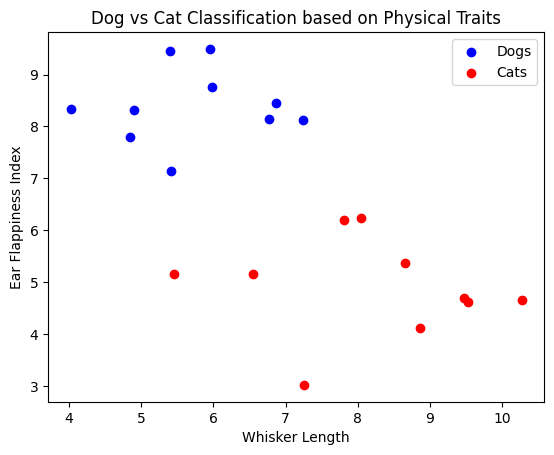

In [281]:
plt.scatter(dogs_whisker_length, dogs_ear_flappiness_index, color='blue', label='Dogs')
plt.scatter(cats_whisker_length, cats_ear_flappiness_index, color='red', label='Cats')
plt.xlabel('Whisker Length')
plt.ylabel('Ear Flappiness Index')
plt.legend()
plt.title('Dog vs Cat Classification based on Physical Traits')
plt.show()

In [282]:
def compute_error(data_dogs, data_cats, theta, theta0):
    error = 0
    for x_dog in data_dogs:
        if np.dot(theta, x_dog) + theta0 <= 0:
            error +=1
    for x_cat in data_cats:
        if np.dot(theta, x_cat) + theta0 > 0:
            error +=1
    return error

In [283]:
# Implementing random linear classifier algorithm

def random_linear_classifier(data_dogs, data_cats, k, d):  # k = choices, d = no of features here 2
    best_error = float('inf')
    best_theta = None
    best_theta0 = None

    for _ in range(k):
        theta = np.random.normal(size=d)
        theta0 = np.random.normal()

        error = compute_error(data_dogs, data_cats, theta, theta0)

        if error < best_error:
            best_error = error
            best_theta = theta
            best_theta0 = theta0
    return best_theta, best_theta0

In [284]:
data_dogs = np.vstack((dogs_whisker_length, dogs_ear_flappiness_index)).T     # concatinate x and y
                                                                            # convert (2 * 10) into (10 * 2) 
data_cats = np.vstack((cats_whisker_length, cats_ear_flappiness_index)).T

In [285]:
data_dogs

array([[6.76405235, 8.14404357],
       [5.40015721, 9.45427351],
       [5.97873798, 8.76103773],
       [7.2408932 , 8.12167502],
       [6.86755799, 8.44386323],
       [4.02272212, 8.33367433],
       [5.95008842, 9.49407907],
       [4.84864279, 7.79484174],
       [4.89678115, 8.3130677 ],
       [5.4105985 , 7.14590426]])

In [286]:
data_cats

array([[ 5.44701018,  5.15494743],
       [ 8.6536186 ,  5.37816252],
       [ 8.8644362 ,  4.11221425],
       [ 7.25783498,  3.01920353],
       [10.26975462,  4.65208785],
       [ 6.54563433,  5.15634897],
       [ 8.04575852,  6.23029068],
       [ 7.81281615,  6.20237985],
       [ 9.53277921,  4.61267318],
       [ 9.46935877,  4.69769725]])

In [287]:
# Run random linear classifire algorithm
k = 100   # no of iteration 
d = 2     # no of features

best_theta, best_theta0 = random_linear_classifier(data_dogs, data_cats, k, d)

In [288]:
best_theta

array([-1.07075262,  1.05445173])

In [289]:
best_theta0

-0.40317694697317963

In [290]:
x_vals = np.linspace(2,10,100)   # plot 100 data points in between 2 and 10 (both included)
y_vals = (-best_theta[0] / best_theta[1]) * x_vals - (best_theta0 / best_theta[1])  # (m * x)

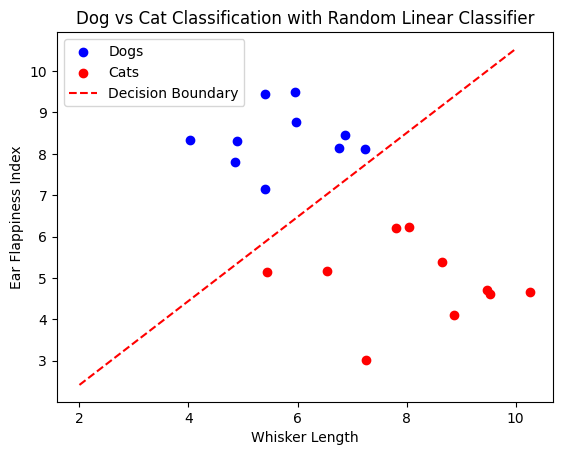

In [291]:
plt.scatter(dogs_whisker_length, dogs_ear_flappiness_index, color='blue', label='Dogs')
plt.scatter(cats_whisker_length, cats_ear_flappiness_index, color='red', label='Cats')
plt.plot(x_vals, y_vals, color='red', linestyle='--', label= 'Decision Boundary')
plt.xlabel('Whisker Length')
plt.ylabel('Ear Flappiness Index')
plt.legend()
plt.title('Dog vs Cat Classification with Random Linear Classifier')
plt.show()